In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Free_Text_Typing_Dataset.csv', sep=';', decimal=',')

print(data.shape)
data.head()

(28412, 15)


,_id,userid,emotionIndex,index,keyCode,keyDown,keyUp,D1U1,D1U2,D1D2,U1D2,U1U2,D1U3,D1D3,answer
0,5e1e2631d2dd163d472fd5ac,100,N,822,\u0011,1.579030e+12,1.579030e+12,9.820000e+02,7.640000e+02,709.0,-2.730000e+02,-2.180000e+02,-1.579030e+12,24124.0,NaN
1,5e1e2631d2dd163d472fd5ad,100,N,823,v,1.579030e+12,1.579030e+12,5.500000e+01,-1.579030e+12,23415.0,2.336000e+04,-1.579030e+12,-1.579030e+12,24022.0,NaN
2,5e1e2631d2dd163d472fd5ae,100,N,824,\b,1.579030e+12,NaN,-1.579030e+12,-1.579030e+12,607.0,1.579030e+12,0.000000e+00,-1.579030e+12,642.0,NaN
3,5e1e2631d2dd163d472fd5af,100,N,825,\b,1.579030e+12,NaN,-1.579030e+12,-1.579030e+12,35.0,1.579030e+12,0.000000e+00,-1.579030e+12,77.0,NaN
4,5e1e2631d2dd163d472fd5b0,100,N,826,\b,1.579030e+12,NaN,-1.579030e+12,-1.579030e+12,42.0,1.579030e+12,0.000000e+00,-1.579030e+12,79.0,NaN


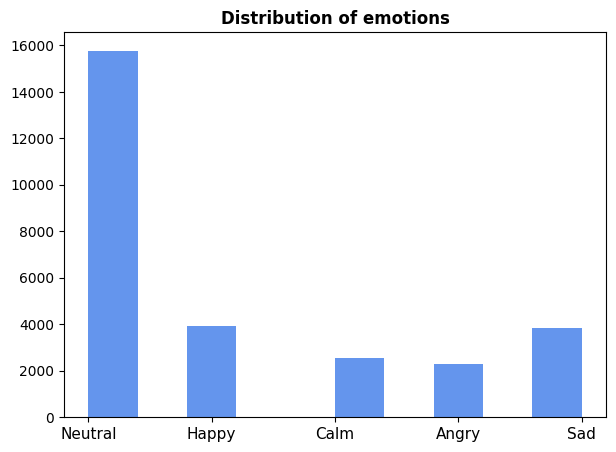

In [4]:
plt.figure(figsize=(7, 5))
plt.title('Distribution of emotions', fontweight='bold')
plt.hist(data['emotionIndex'], color='cornflowerblue')
plt.xticks([0, 1, 2, 3, 4], ['Neutral', 'Happy', 'Calm', 'Angry', 'Sad'],fontsize=11)
plt.show()

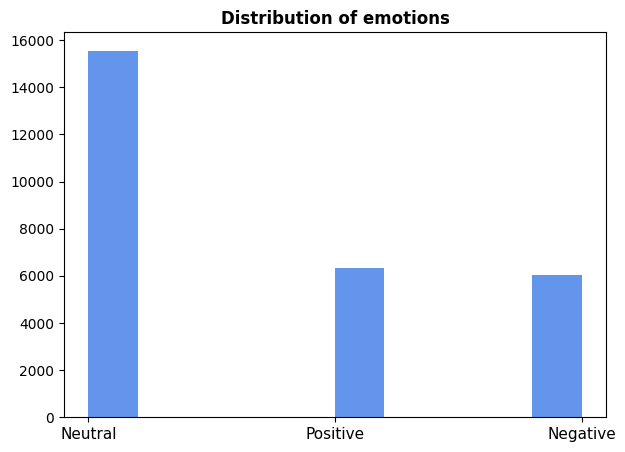

In [9]:
data = pd.read_csv('Free_Text_EmoSurv.csv')

emotion_mapping = {
    0: 2,  # Angry -> Negative
    1: 1,  # Calm -> Positive
    2: 1,  # Happy -> Positive
    3: 0,  # Neutral -> Neutral
    4: 2   # Sad -> Negative
}

data['emotionIndex'] = data['emotionIndex'].map(emotion_mapping)

plt.figure(figsize=(7, 5))
plt.title('Distribution of emotions', fontweight='bold')
plt.hist(data['emotionIndex'], color='cornflowerblue')
plt.xticks([0, 1, 2], ['Neutral', 'Positive', 'Negative'],fontsize=11)
plt.show()

In [5]:
import pandas as pd
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

from utils import plot_train_dynamics, create_sequences
from attention_gru import DetectorAttentionGRU

In [6]:
data = pd.read_csv('Free_Text_EmoSurv.csv')

emotion_mapping = {
    0: 2,  # Angry -> Negative
    1: 1,  # Calm -> Positive
    2: 1,  # Happy -> Positive
    3: 0,  # Neutral -> Neutral
    4: 2   # Sad -> Negative
}

data['emotionIndex'] = data['emotionIndex'].map(emotion_mapping)

users = data['userid'].unique().tolist()
train_users, test_users = train_test_split(users, test_size = 0.3, random_state = 0) # делим на train и test по пользователям

train_data = data[data['userid'].isin(train_users)].copy()
test_data = data[data['userid'].isin(test_users)].copy()

test_users, valid_users = train_test_split(test_users, test_size = 0.5, random_state = 0) # дополнительно выделим валидационную выборку

test_data = data[data['userid'].isin(test_users)].copy()
valid_data = data[data['userid'].isin(valid_users)].copy()

feature_cols = ['D1U1', 'D1U2', 'D1D2', 'U1D2', 'U1U2', 'D1U3', 'D1D3', 'is_punctuation', 'is_backspace', 'is_enter', 'hour']

scaler_X = StandardScaler()
train_data[feature_cols] = scaler_X.fit_transform(train_data[feature_cols])
test_data[feature_cols] = scaler_X.transform(test_data[feature_cols])
valid_data[feature_cols] = scaler_X.transform(valid_data[feature_cols])

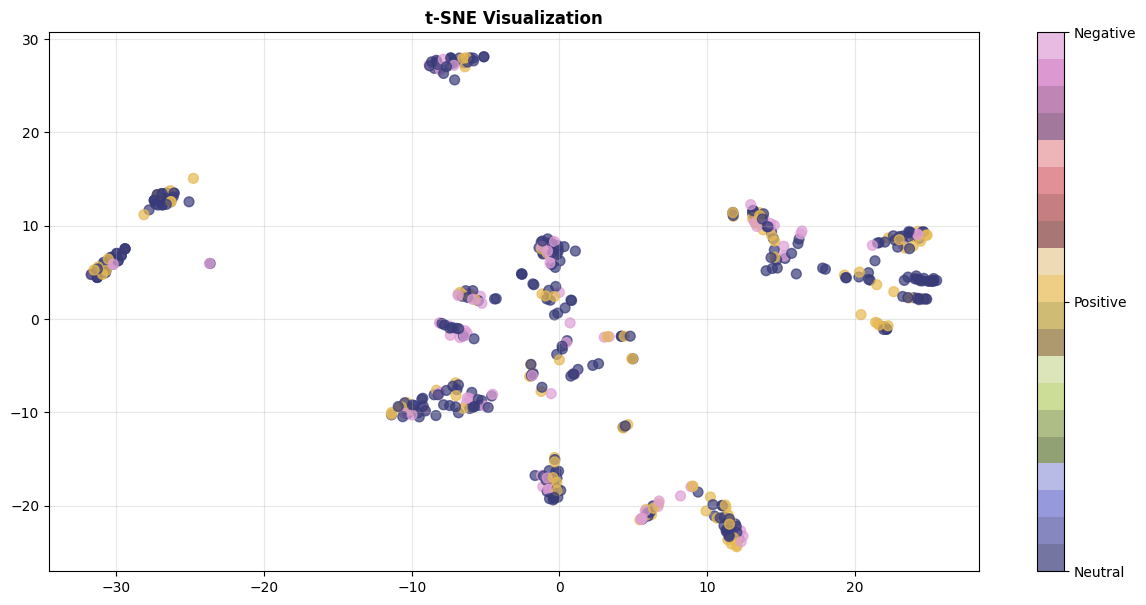

In [8]:
from sklearn.manifold import TSNE

X = train_data[feature_cols].copy()
y = train_data['emotionIndex'].copy()

np.random.seed(0)
random_indices = np.random.choice(len(X), size = 500, replace = False)

X_sample = X.iloc[random_indices]
y_sample = y.iloc[random_indices]


tsne = TSNE(n_components = 2, random_state = 0, perplexity = 30, early_exaggeration = 12)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(15, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab20b', s=50, alpha=0.7)
plt.title('t-SNE Visualization', fontweight='bold')

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Neutral', 'Positive', 'Negative'])

plt.grid(alpha=0.3)
plt.show()